In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as st

In [ ]:
# Read the files
df_companies = pd.read_csv('/datasets/project_sql_result_01.csv')
df_locations = pd.read_csv('/datasets/project_sql_result_04.csv')

In [ ]:
# Check data types and look for missing values
print("####Companies Info#####")
df_companies.info()
df_companies.head()

####Companies Info#####
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasing,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


In [ ]:
print("\n#### Locations Info ####")
df_locations.info()
df_locations.head()


#### Locations Info ####
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


In [ ]:
# Sort by average trips and grab the top 10 neighborhoods
top_10_neighborhoods = df_locations.sort_values(by='average_trips', ascending=False).head(10)
top_10_neighborhoods

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


In [ ]:
# Sort by trips amount and grab the top 15 companies
top_15_companies = df_companies.sort_values(by='trips_amount', ascending=False).head(15)
top_15_companies

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasing,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299
5,Chicago Carriage Cab Corp,9181
6,City Service,8448
7,Sun Taxi,7701
8,Star North Management LLC,7455
9,Blue Ribbon Taxi Association Inc.,5953


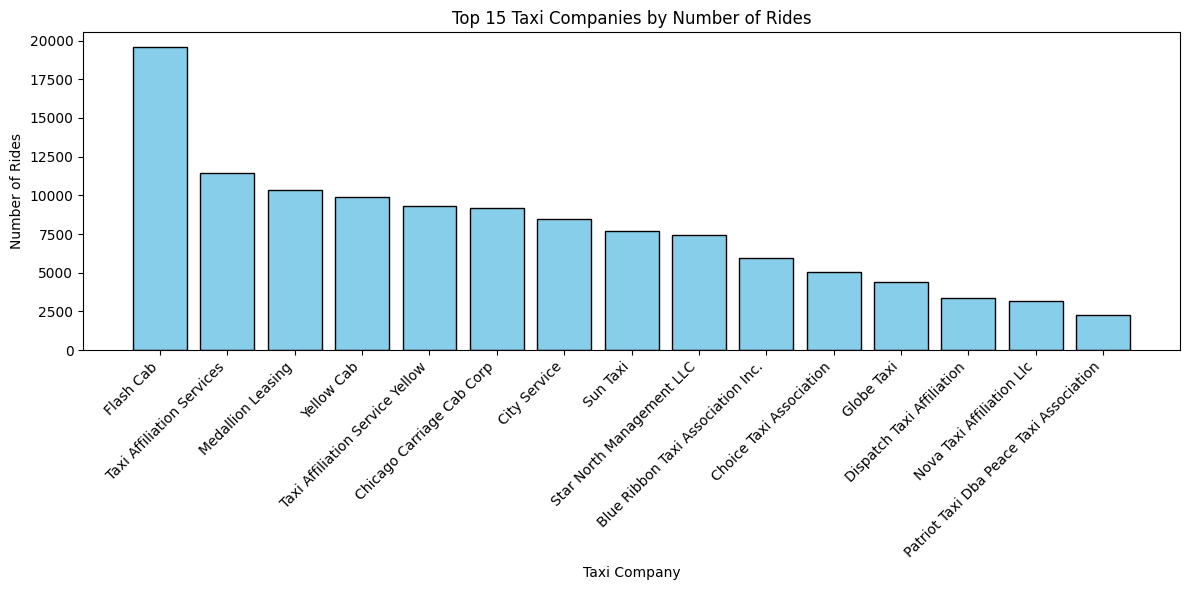

In [ ]:
# Graph 1: Taxi Companies and Number of Rides (Top 15)
plt.figure(figsize=(12, 6))

plt.bar(top_15_companies['company_name'], top_15_companies['trips_amount'], color='skyblue', edgecolor='black')

plt.title('Top 15 Taxi Companies by Number of Rides')
plt.xlabel('Taxi Company')
plt.ylabel('Number of Rides')

# Rotate the labels so they don't overlap
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The market is  dominated by the  company Flash Cab, which has significantly more rides than its closest competitors. There is a steep drop-off in ride volume after the top few companies, showing that a few major players control most of the market share.

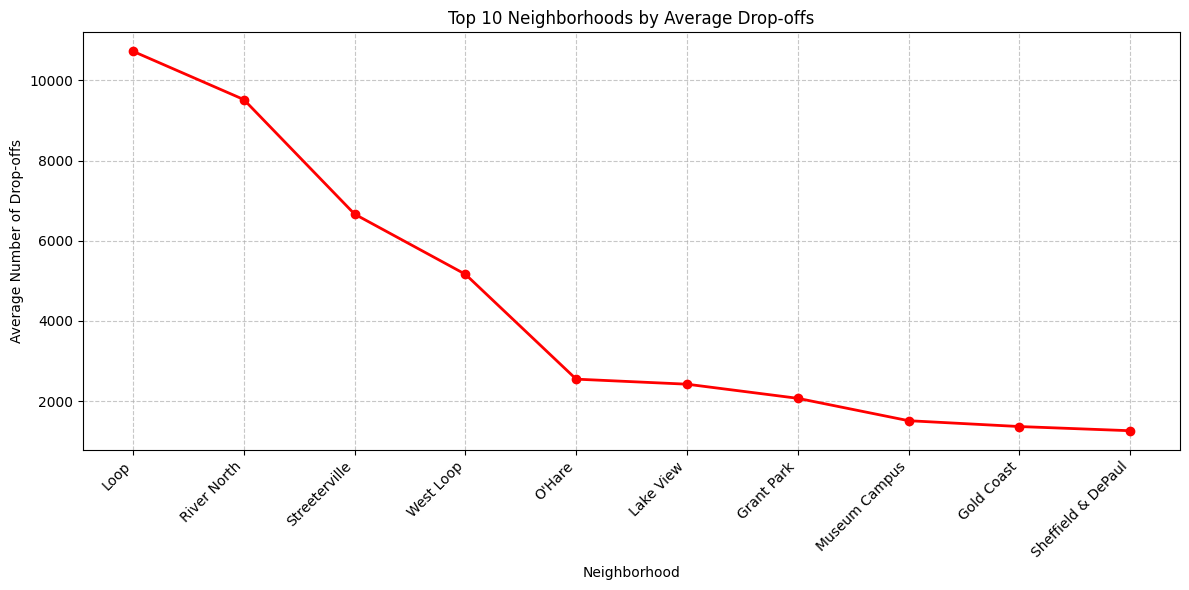

In [ ]:
# Graph 2: Top 10 Neighborhoods by Number of Drop-offs
plt.figure(figsize=(12, 6))

plt.plot(top_10_neighborhoods['dropoff_location_name'], top_10_neighborhoods['average_trips'],
         color='red', marker='o', linestyle='-', linewidth=2, markersize=6)

plt.title('Top 10 Neighborhoods by Average Drop-offs')
plt.xlabel('Neighborhood')
plt.ylabel('Average Number of Drop-offs')

# Adding a grid helps with reading values on a line chart
plt.grid(True, linestyle='--', alpha=0.7)

# Rotate the labels so they don't overlap
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The top drop-off locations are centrally located commercial and tourist hubs like the Loop, River North, and Streeterville. This is expected, as these areas have high foot traffic, businesses, and attractions, making them the primary destinations for passengers.

In [ ]:
df_loop_ohare = pd.read_csv('/datasets/project_sql_result_07.csv')

In [ ]:
# Inspect the data to ensure proper types and check for missing values
df_loop_ohare.info()
df_loop_ohare.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB


,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0


In [ ]:
# Drop any rows with missing duration data just to be safe
df_loop_ohare = df_loop_ohare.dropna(subset=['duration_seconds'])

# Convert the 'start_ts' column from a string (object) to a datetime object
df_loop_ohare['start_ts'] = pd.to_datetime(df_loop_ohare['start_ts'])
df_loop_ohare.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[ns]
 1   weather_conditions  1068 non-null   object        
 2   duration_seconds    1068 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 33.4+ KB


In [ ]:
# Create two separate arrays for good and bad weather durations
good_weather_durations = df_loop_ohare[df_loop_ohare['weather_conditions'] == 'Good']['duration_seconds']
bad_weather_durations = df_loop_ohare[df_loop_ohare['weather_conditions'] == 'Bad']['duration_seconds']

In [ ]:
print(f"Sample size for Good weather: {len(good_weather_durations)}")
print(f"Sample size for Bad weather: {len(bad_weather_durations)}")

Sample size for Good weather: 888
Sample size for Bad weather: 180


In [ ]:
# Set the statistical significance level
alpha = 0.05

* **Null Hypothesis ($H_0$):** The average duration of rides from the Loop to O'Hare International Airport **does not change** on Saturdays with "Bad" weather (rain or storms) compared to Saturdays with "Good" weather. (The average duration on "Bad" weather Saturdays equals the average duration on "Good" weather Saturdays).

  
* **Alternative Hypothesis ($H_1$):** The average duration of rides from the Loop to O'Hare International Airport **changes** on Saturdays with "Bad" weather compared to Saturdays with "Good" weather. (The average duration on "Bad" weather Saturdays differs from "Good" weather Saturdays).

**Choosing the Statistical Test**


* **Criterion used:** We are using an **Independent Samples t-test** (`scipy.stats.ttest_ind`) because we are comparing the means of two independent statistical populations (ride durations during "Good" weather vs. "Bad" weather).

  
* **Why Welch's t-test?** We will set the parameter `equal_var=False` to perform a Welch's t-test. This is necessary because we cannot assume the variances of our two populations are equal—especially since the sample size of "Good" weather days is likely  larger than "Bad" weather days. We will use a standard significance level ($\alpha$) of **0.05**.

In [ ]:
# Test the hypothesis using an independent two-sample t-test
# We set equal_var=False because the sample sizes and variances are likely different
results = st.ttest_ind(good_weather_durations, bad_weather_durations, equal_var=False)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print("We reject the null hypothesis.")
else:
    print("We can't reject the null hypothesis.")

p-value: 6.738994326108734e-12
We reject the null hypothesis.


Based on the independent two-sample t-test, our p-value was significantly lower than our alpha of 0.05. Therefore, we reject the null hypothesis.

This means there is a statistically significant difference in ride durations depending on the weather. The data supports the alternative hypothesis that the average duration of rides from the Loop to O'Hare International Airport does indeed change on rainy Saturdays.